# Introduction to Deep Learning, Assignment 2, Task 2

# Introduction


The goal of this assignment is to learn how to use encoder-decoder recurrent neural networks (RNNs). Specifically we will be dealing with a sequence to sequence problem and try to build recurrent models that can learn the principles behind simple arithmetic operations (**integer addition, subtraction and multiplication.**).

<img src="https://i.ibb.co/5Ky5pbk/Screenshot-2023-11-10-at-07-51-21.png" alt="Screenshot-2023-11-10-at-07-51-21" border="0" width="500"></a>

In this assignment you will be working with three different kinds of models, based on input/output data modalities:
1. **Text-to-text**: given a text query containing two integers and an operand between them (+ or -) the model's output should be a sequence of integers that match the actual arithmetic result of this operation
2. **Image-to-text**: same as above, except the query is specified as a sequence of images containing individual digits and an operand.
3. **Text-to-image**: the query is specified in text format as in the text-to-text model, however the model's output should be a sequence of images corresponding to the correct result.


### Description
Let us suppose that we want to develop a neural network that learns how to add or subtract
two integers that are at most two digits long. For example, given input strings of 5 characters: ‘81+24’ or
’41-89’ that consist of 2 two-digit long integers and an operand between them, the network should return a
sequence of 3 characters: ‘105 ’ or ’-48 ’ that represent the result of their respective queries. Additionally,
we want to build a model that generalizes well - if the network can extract the underlying principles behind
the ’+’ and ’-’ operands and associated operations, it should not need too many training examples to generate
valid answers to unseen queries. To represent such queries we need 13 unique characters: 10 for digits (0-9),
2 for the ’+’ and ’-’ operands and one for whitespaces ’ ’ used as padding.
The example above describes a text-to-text sequence mapping scenario. However, we can also use different
modalities of data to represent our queries or answers. For that purpose, the MNIST handwritten digit
dataset is going to be used again, however in a slightly different format. The functions below will be used to create our datasets.

---

*To work on this notebook you should create a copy of it.*

When using the Lab Computers, download the Jupyter Notebook to one of the machines first.

If you want to use Google Colab, you should first copy this notebook and enable GPU runtime in 'Runtime -> Change runtime type -> Hardware acceleration -> GPU **OR** TPU'.


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [30]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell
from tensorflow.keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose

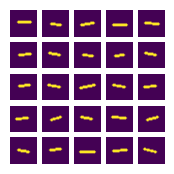

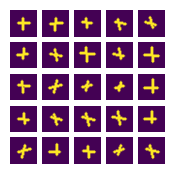

In [2]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [3]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #8068

X_text: "40+34" = y_text: "74 "


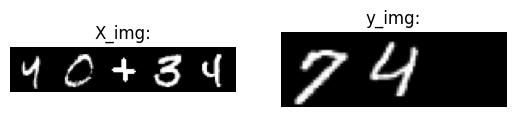

Query #6961

X_text: "34-80" = y_text: "-46"


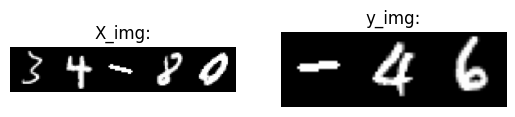

Query #8826

X_text: "44+13" = y_text: "57 "


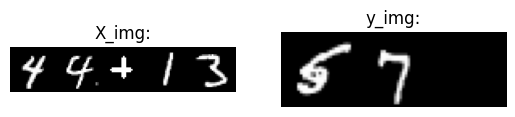

Query #8612

X_text: "43+6 " = y_text: "49 "


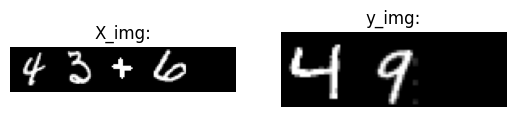

Query #3299

X_text: "16-49" = y_text: "-33"


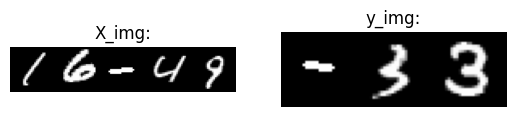

Query #2654

X_text: "13+27" = y_text: "40 "


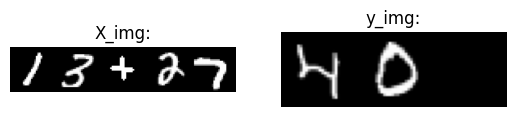

Query #662

X_text: "3+31 " = y_text: "34 "


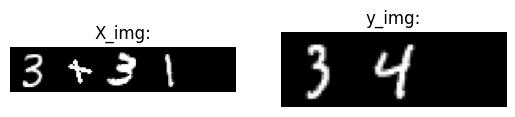

Query #3108

X_text: "15+54" = y_text: "69 "


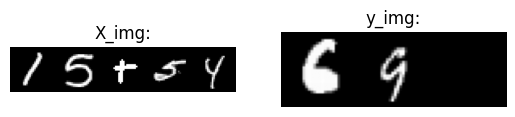

Query #3018

X_text: "15+9 " = y_text: "24 "


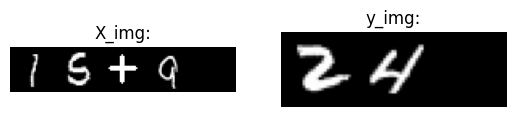

Query #5395

X_text: "26-97" = y_text: "-71"


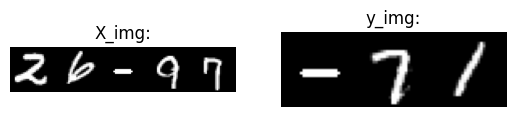

In [4]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [ ]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([unique_characters[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [6]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text


---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

### Model using a ConvLTSM2D layer and teacher forcing

In [108]:
# Teacher forcing preparation
vocabulary_tf = list(unique_characters)+['<SOS>','<EOS>','<PAD>']

indices = {char:i for i, char in enumerate(vocabulary_tf)}
reverse_indices={i:char for i,char in enumerate(vocabulary_tf)}


# One-hot encoding
def encode_labels_tf(labels, vocabulary=vocabulary_tf, indices_map=indices):
  n = len(labels)
  length = len(labels[0])+2 # for start of sequence <SOS> and end of sequence <EOS> tokens.

  one_hot = np.zeros([n, length, len(vocabulary)])
  for i, label in enumerate(labels):
    full_label = ['<SOS>'] + list(label) + ['<EOS>']
    m = np.zeros([length, len(vocabulary)])
    for j, char in enumerate(full_label):
       m[j, indices_map[char]] = 1
    one_hot[i] = m

  return one_hot

# One-hot decoding
def decode_labels_tf(labels, vocabulary=vocabulary_tf, indices_map = reverse_indices):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([indices_map[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels_tf(X_text)
y_text_onehot = encode_labels_tf(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 7, 16) (20000, 5, 16)


In [ ]:
## Your code is: damn code

from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D, LSTM, TimeDistributed, Dropout, Input
from tensorflow.keras.optimizers import Adam



# First we create a build-encoder function
def build_image2text_encoder(dropout, max_size=512):
    
    # Initialize an encoder
    encoder = tf.keras.Sequential()

    ## Build encoder layers
    # Block 1
    encoder.add(TimeDistributed(
            Conv2D(32, (3,3), padding = "same"),
            input_shape = (5,28,28,1))) # 5 times a grayscale image
    encoder.add(TimeDistributed(BatchNormalization(), name='BN1'))
    encoder.add(TimeDistributed(Activation('relu'), name='acti1'))
    encoder.add(TimeDistributed(Dropout(dropout), name='DO1'))
    encoder.add(TimeDistributed(MaxPooling2D(), name='MP2D_1'))
    
    # Block 2
    encoder.add(TimeDistributed(
            Conv2D(64, (3,3), padding = "same")))
    encoder.add(TimeDistributed(BatchNormalization()))
    encoder.add(TimeDistributed(Activation('relu')))
    encoder.add(TimeDistributed(Dropout(dropout)))
    encoder.add(TimeDistributed(MaxPooling2D()))

    # Recurrent convolutional layers
    encoder.add(
        ConvLSTM2D(filters=128, kernel_size=(3,3), padding='same',return_sequences=False, use_bias=False, return_state=True, name='ConvLSTM')
    )

    return encoder


# Secondly we create a build-decoder function
def build_image2text_decoder(dropout, max_size=512): # tfi = teacher forcing input

    lstm = LSTM(max_size, return_sequences = True, dropout = dropout, recurrent_dropout = dropout)
    dense = TimeDistributed(Dense(len(teacher_forcing_vocab), activation='softmax'))

    return lstm, dense

# Here we build the full model
def build_image2text(dropout = 0.3, max_size=512, learning_rate = 2.5e-4, max_answer_length_tf=4):


    ## Define input layer of full model
    X_in = Input(shape = (5,28,28,1), name = 'sequence')
    Y_in = Input(shape=(max_answer_length_tf, len(teacher_forcing_vocab)))


    ## Encoder step
    encoder = build_image2text_encoder(dropout)
    output, hidden, cell = encoder(X_in)


    ## Bridge step
    # We take the output hidden and cell state of the encoder so that we may use teacher forcing.
    hidden_flatten = Flatten()(hidden)
    h_initial = Dense(max_size, activation = 'relu', name='h0')(hidden_flatten)

    cell_flatten = Flatten()(cell)
    c_initial = Dense(max_size, activation = 'relu', name='c0')(cell_flatten)

    ini_state = [h_initial, c_initial]

    ## Decoder step
    # We initialize the decoder using teacher forcing
    decoder_lstm, decoder_dense = build_image2text_decoder(dropout)
    y_lstm = decoder_lstm(Y_in, initial_state = ini_state)
    y_out = decoder_dense(y_lstm)

    ## Full model step
    full = tf.keras.Model(inputs=[X_in, Y_in], outputs = y_out)
    full.compile(
        loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy']
    )

    full.summary(expand_nested=True)
    return full

In [110]:
size=0.15

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_text_onehot, random_state=42, test_size=size
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, random_state=42, test_size=size/(1-size)
)

y_train_in = y_train[:, :-1, :]
y_train_target = y_train[:, 1:, :]

y_val_in = y_val[:, :-1, :]
y_val_target = y_val[:, 1:, :]

### Training the image-to-text model

In [116]:
image2text = build_image2text(dropout=0.5)

early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=7,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

image2text.fit(x=[X_train, y_train_in], y=y_train_target,
               epochs = 60,
               batch_size = 32,
               validation_data = ([X_val, y_val_in], y_val_target),
               callbacks=[lr_scheduler, early_stopper])

/vol/home/s2358441/.conda/envs/IDL/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_349"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 5, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_41       │ [(None, 7, 7,     │    903,936 │ sequence[0][0]    │
│ (Sequential)        │ 128), (None, 7,   │            │                   │
│                     │ 7, 128), (None,   │            │                   │
│                     │ 7, 7, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 28, 28, │        320 │ -                 │
│ time_distributed_2… │ 32)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ BN1            │ (None, 5, 28, 28, │        128 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ acti1          │ (None, 5, 28, 28, │          0 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ DO1            │ (None, 5, 28, 28, │          0 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ MP2D_1         │ (None, 5, 14, 14, │          0 │ -                 │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │     18,496 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │        256 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 14, 14, │          0 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ (None, 5, 7, 7,   │          0 │ -                 │
│ time_distributed_2… │ 64)               │            │                   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └ ConvLSTM       │ [(None, 7, 7,     │    884,736 │ -                 │
│ (ConvLSTM2D)        │ 128), (None, 7,   │            │                   │
│                     │ 7, 128), (None,   │            │                   │
│                     │ 7, 7, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,419,088 (32.12 MB)

 Trainable params: 8,418,896 (32.12 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/60


E0000 00:00:1765043105.070537 1891829 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: MutableGraphView::SortTopologically error: detected edge(s) creating cycle(s) {'StatefulPartitionedCall/functional_349_1/sequential_41_1/ConvLSTM_1/while/body/_77/functional_349_1/sequential_41_1/ConvLSTM_1/while/conv_lstm_cell_1/mul' -> 'StatefulPartitionedCall/functional_349_1/sequential_41_1/ConvLSTM_1/while/body/_77/functional_349_1/sequential_41_1/ConvLSTM_1/while/conv_lstm_cell_1/add_3', 'StatefulPartitionedCall/gradient_tape/functional_349_1/sequential_41_1/ConvLSTM_1/while/functional_349_1/sequential_41_1/ConvLSTM_1/while_grad/body/_832/gradient_tape/functional_349_1/sequential_41_1/ConvLSTM_1/while/gradients/functional_349_1/sequential_41_1/ConvLSTM_1/while/conv_lstm_cell_1/Tanh_1_grad/TanhGrad' -> 'StatefulPartitionedCall/gradient_tape/functional_349_1/sequential_41_1/ConvLSTM_1/while/functional_349_1/sequential_41_1/ConvLSTM_1/while_grad/body/_832/gradient_tape/functional_349_1/sequ

438/438 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5217 - loss: 1.4741 - val_accuracy: 0.5382 - val_loss: 1.5258 - learning_rate: 2.5000e-04
Epoch 2/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.5579 - loss: 1.2702 - val_accuracy: 0.5016 - val_loss: 1.6166 - learning_rate: 2.5000e-04
Epoch 3/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.5715 - loss: 1.1943 - val_accuracy: 0.5412 - val_loss: 1.3625 - learning_rate: 2.5000e-04
Epoch 4/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.5869 - loss: 1.1393 - val_accuracy: 0.5434 - val_loss: 1.3374 - learning_rate: 2.5000e-04
Epoch 5/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.5999 - loss: 1.0969 - val_accuracy: 0.5486 - val_loss: 1.3266 - learning_rate: 2.5000e-04
Epoch 6/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6139 - loss: 1.0544 - val_accuracy: 0.5868 - val_loss: 1.1498 - learning_rate: 2.5000e-04
Epoch 7/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accurac

(16470, 3, 13)

#### Notes

using dropout=0.3 end with accuracy: 0.9814 - loss: 0.1026 - val_accuracy: 0.6991 - val_loss: 1.0644

### Attempt 2

In [ ]:
size=0.15

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_text_onehot, random_state=42, test_size=size
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, random_state=42, test_size=size/(1-size)
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_test.shape, y_val.shape)
y_train[2:3]

In [ ]:
## Your code is: damn code
dropout = 0.3

from keras.layers import BatchNormalization, Activation, MaxPooling2D, RepeatVector, LSTM, TimeDistributed, Input, Dropout
from keras.optimizers import Adam

# First we create a build-encoder function
def build_image2text_encoder():
    
    # Initialize an encoder
    encoder = tf.keras.Sequential()

    ## Build encoder layers
    # Block 1
    encoder.add(TimeDistributed(
            Conv2D(32, (3,3), padding = "same"),
            input_shape = (5,28,28,1))) # 5 times a grayscale image
    encoder.add(TimeDistributed(BatchNormalization()))
    encoder.add(TimeDistributed(Activation('relu')))
    encoder.add(TimeDistributed(Dropout(dropout)))
    encoder.add(TimeDistributed(MaxPooling2D()))
    
    # Block 2
    encoder.add(TimeDistributed(
            Conv2D(64, (3,3), padding = "same")))
    encoder.add(TimeDistributed(BatchNormalization()))
    encoder.add(TimeDistributed(Activation('relu')))
    encoder.add(TimeDistributed(Dropout(dropout)))
    encoder.add(TimeDistributed(MaxPooling2D()))

    # Recurrent convolutional layers
    encoder.add(
        ConvLSTM2D(filters=128, kernel_size=(3,3), padding='same',return_sequences=False, use_bias=False)
    )

    ## Shape into format needed for the decoder
    encoder.add(Flatten())
    encoder.add(Dense(Dense_layer_size, activation='relu'))
    encoder.add(Dropout(dropout))

    return encoder


# Secondly we create a build-decoder function
def build_image2text_decoder():

    # Initialize decoder
    decoder = tf.keras.Sequential()
    ## Build decoder layers
    decoder.add(RepeatVector(max_answer_length, input_shape = (Dense_layer_size,)))
    decoder.add(LSTM(Dense_layer_size, return_sequences = True, dropout = dropout, recurrent_dropout = dropout))
    decoder.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    return decoder


# Here we build the full model
def build_image2text():

    ## We build the full model by sticking the encoder and decoder together.
    # First we initialize the encoder and decoder.
    encoder = build_image2text_encoder()
    decoder = build_image2text_decoder()

    # Define input layer of full model
    X_in = tf.keras.Input(shape = (5,28,28,1))

    # Concatanate the encoder and decoder
    encoded_vector = encoder(X_in)
    y_out = decoder(encoded_vector)

    # Build the full model
    full = tf.keras.Model(inputs=X_in, outputs = y_out)
    full.compile(
        loss='categorical_crossentropy', optimizer=Adam(learning_rate=2.5e-4), metrics=['accuracy']
    )

    full.summary(expand_nested=True)
    return full